In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("../data/nasdaq/csv/AAPL.csv")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [3]:
features = [
    "Low",
    "Open",
    "Volume",
    "High",
    "Close",
    "Adjusted Close"
]

target_col = "Close"

close_index = features.index(target_col)

data = df[features].copy()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(10590, 6)


In [4]:
def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):

    train_size = int(len(X) * train_ratio)

    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [5]:
def build_lstm_model(
    window_size,
    num_features,
    output_size
):

    model = Sequential()

    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=(window_size, num_features)
        )
    )

    model.add(Dropout(0.2))

    model.add(
        LSTM(
            32,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(output_size))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )

    return model

In [6]:
def plot_training_history(history, title, save_path):
    plt.figure(figsize=(12, 5))

    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.yscale("log")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.legend()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [7]:
def evaluate_prediction(y_true, y_pred, title, save_path):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(title)
    print("RMSE:", rmse)
    print("MAE:", mae)

    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Test Sample")
    plt.ylabel("Normalized Close Price")
    plt.legend()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return rmse, mae

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [9]:
def create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):

    X = []
    y = []

    for i in range(
        window_size,
        len(scaled_data) - k + 1
    ):

        X.append(
            scaled_data[i-window_size:i]
        )

        y.append(
            scaled_data[i + k - 1, close_index]
        )

    return np.array(X), np.array(y)

In [10]:
window_size = 30

k_day = 7

X_1_2, y_1_2 = create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k_day
)

print(X_1_2.shape)
print(y_1_2.shape)

(10554, 30, 6)
(10554,)


In [11]:
X_train_1_2, X_val_1_2, X_test_1_2, \
y_train_1_2, y_val_1_2, y_test_1_2 = chronological_split(
    X_1_2,
    y_1_2
)

In [12]:
model_task_1_2_lstm = build_lstm_model(
    window_size,
    len(features),
    1
)

model_task_1_2_lstm.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,769 (128.00 KB)

 Trainable params: 32,769 (128.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_1_2_lstm = model_task_1_2_lstm.fit(
    X_train_1_2,
    y_train_1_2,
    validation_data=(
        X_val_1_2,
        y_val_1_2
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - loss: 1.1495e-05 - mae: 0.0018 - val_loss: 3.9788e-04 - val_mae: 0.0162
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 3.1702e-06 - mae: 0.0011 - val_loss: 3.6265e-04 - val_mae: 0.0159
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 2.7764e-06 - mae: 0.0010 - val_loss: 1.5283e-04 - val_mae: 0.0099
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 2.2133e-06 - mae: 9.0570e-04 - val_loss: 2.5633e-04 - val_mae: 0.0137
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 2.1567e-06 - mae: 9.0369e-04 - val_loss: 1.1916e-04 - val_mae: 0.0089
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 2.0198e-06 - mae: 8.6377e-04 - val_loss: 4.0609e-04 - val_mae: 0.0178
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.8393e-06 - mae: 8.2608e-04 - val_loss: 1.4983e-04 - val_mae: 0.0101
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 1.8743e-06 - mae: 8.348

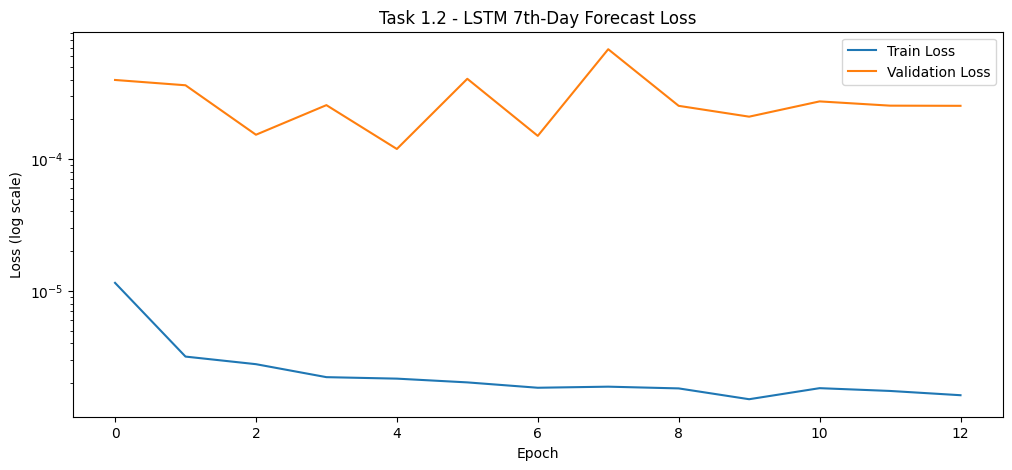

In [14]:
plot_training_history(
    history_1_2_lstm,
    "Task 1.2 - LSTM 7th-Day Forecast Loss",
    "../results/figures/task1_2_lstm_loss_curve.png"
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Task 1.2 - LSTM 7th-Day Forecast
RMSE: 0.1857518819904331
MAE: 0.1341043733026213


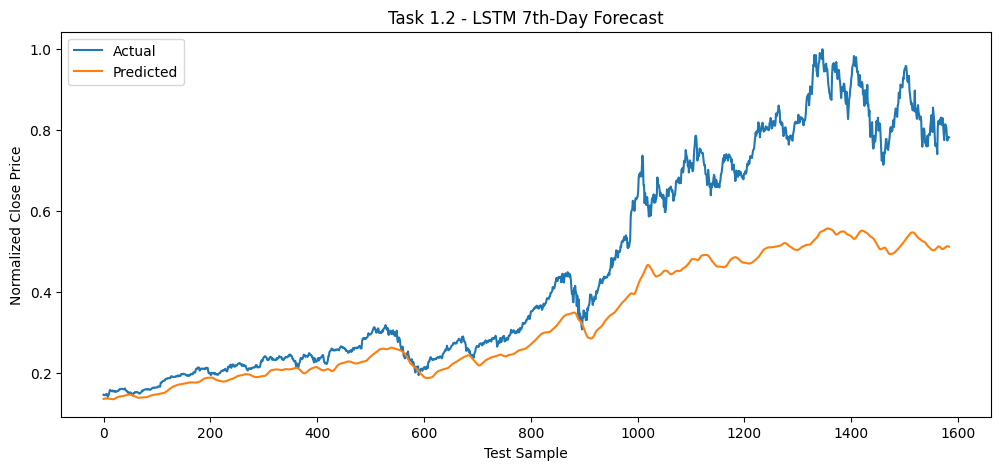

In [15]:
pred_1_2_lstm = model_task_1_2_lstm.predict(X_test_1_2)

rmse_1_2_lstm, mae_1_2_lstm = evaluate_prediction(
    y_test_1_2,
    pred_1_2_lstm,
    "Task 1.2 - LSTM 7th-Day Forecast",
    "../results/figures/task1_2_lstm_actual_vs_predicted.png"
)

In [16]:
model_task_1_2_lstm.save("../models/task1_2_lstm_kth_day.keras")

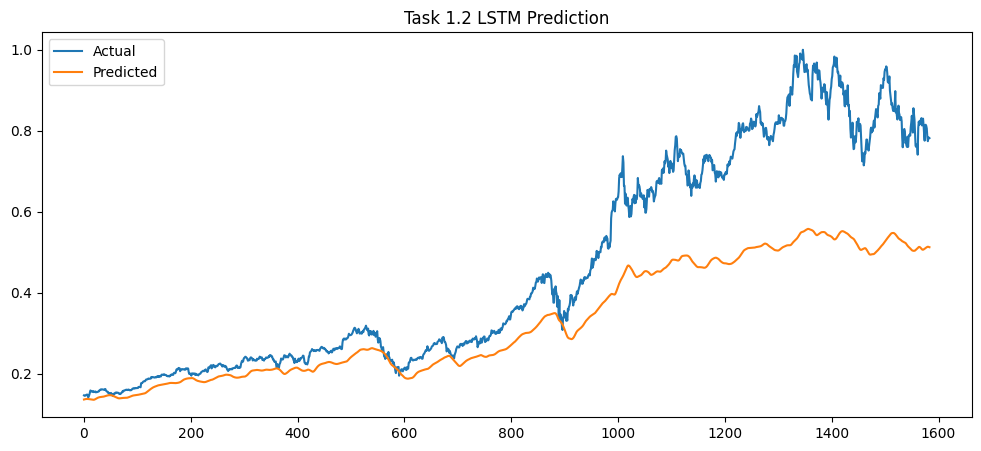

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_1_2,
    label="Actual"
)

plt.plot(
    pred_1_2_lstm,
    label="Predicted"
)

plt.title(
    "Task 1.2 LSTM Prediction"
)

plt.legend()

plt.show()

In [18]:
def create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):

    X = []
    y = []

    for i in range(
        window_size,
        len(scaled_data) - k + 1
    ):

        X.append(
            scaled_data[i-window_size:i]
        )

        y.append(
            scaled_data[i:i+k, close_index]
        )

    return np.array(X), np.array(y)

In [19]:
k_days = 7

X_1_3, y_1_3 = create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k_days
)

print(X_1_3.shape)
print(y_1_3.shape)

(10554, 30, 6)
(10554, 7)


In [20]:
X_train_1_3, X_val_1_3, X_test_1_3, \
y_train_1_3, y_val_1_3, y_test_1_3 = chronological_split(
    X_1_3,
    y_1_3
)

In [21]:
model_task_1_3_lstm = build_lstm_model(
    window_size,
    len(features),
    k_days
)

model_task_1_3_lstm.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,159 (129.53 KB)

 Trainable params: 33,159 (129.53 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_1_3_lstm = model_task_1_3_lstm.fit(
    X_train_1_3,
    y_train_1_3,
    validation_data=(
        X_val_1_3,
        y_val_1_3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - loss: 1.1454e-05 - mae: 0.0017 - val_loss: 1.1008e-04 - val_mae: 0.0084
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3.1238e-06 - mae: 0.0011 - val_loss: 1.1253e-04 - val_mae: 0.0085
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 2.5109e-06 - mae: 9.8601e-04 - val_loss: 5.1818e-05 - val_mae: 0.0055
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 2.2660e-06 - mae: 9.4767e-04 - val_loss: 1.0131e-04 - val_mae: 0.0081
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 2.1310e-06 - mae: 9.2055e-04 - val_loss: 2.0283e-04 - val_mae: 0.0118
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 2.0403e-06 - mae: 9.0716e-04 - val_loss: 8.7977e-05 - val_mae: 0.0070
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 1.9833e-06 - mae: 9.0329e-04 - val_loss: 1.3834e-04 - val_mae: 0.0095
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.8476e-06 - mae: 8

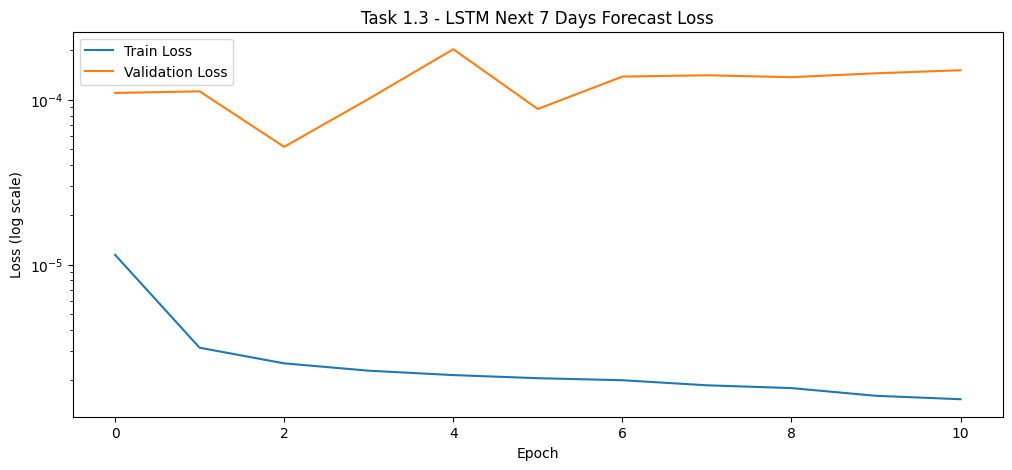

In [23]:
plot_training_history(
    history_1_3_lstm,
    "Task 1.3 - LSTM Next 7 Days Forecast Loss",
    "../results/figures/task1_3_lstm_loss_curve.png"
)

In [24]:
pred_1_3_lstm = model_task_1_3_lstm.predict(X_test_1_3)

rmse_1_3_lstm = np.sqrt(
    mean_squared_error(
        y_test_1_3.flatten(),
        pred_1_3_lstm.flatten()
    )
)

mae_1_3_lstm = mean_absolute_error(
    y_test_1_3.flatten(),
    pred_1_3_lstm.flatten()
)

print("Task 1.3 - LSTM Next 7 Days Forecast")
print("RMSE:", rmse_1_3_lstm)
print("MAE:", mae_1_3_lstm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Task 1.3 - LSTM Next 7 Days Forecast
RMSE: 0.1814366256170401
MAE: 0.12358184093896439


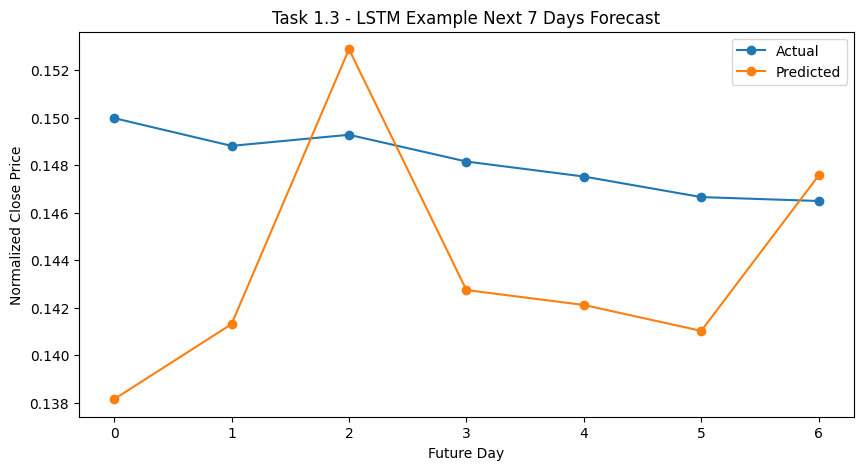

In [25]:
sample_index = 0

plt.figure(figsize=(10, 5))

plt.plot(
    y_test_1_3[sample_index],
    marker="o",
    label="Actual"
)

plt.plot(
    pred_1_3_lstm[sample_index],
    marker="o",
    label="Predicted"
)

plt.title("Task 1.3 - LSTM Example Next 7 Days Forecast")
plt.xlabel("Future Day")
plt.ylabel("Normalized Close Price")
plt.legend()

plt.savefig(
    "../results/figures/task1_3_lstm_example_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
model_task_1_3_lstm.save("../models/task1_3_lstm_k_days.keras")

In [27]:
task1_lstm_results = pd.DataFrame({
    "Task": [
        "Task 1.2 - 7th day prediction",
        "Task 1.3 - Next 7 days prediction"
    ],
    "Model": [
        "LSTM",
        "LSTM"
    ],
    "RMSE": [
        rmse_1_2_lstm,
        rmse_1_3_lstm
    ],
    "MAE": [
        mae_1_2_lstm,
        mae_1_3_lstm
    ]
})

task1_lstm_results

,Task,Model,RMSE,MAE
0,Task 1.2 - 7th day prediction,LSTM,0.185752,0.134104
1,Task 1.3 - Next 7 days prediction,LSTM,0.181437,0.123582


In [28]:
task1_lstm_results.to_csv(
    "../results/metrics/task1_lstm_results.csv",
    index=False
)

print("Task 1 LSTM results saved successfully.")

Task 1 LSTM results saved successfully.


In [29]:
task1_lstm_results_rounded = task1_lstm_results.copy()

task1_lstm_results_rounded["RMSE"] = task1_lstm_results_rounded["RMSE"].round(4)
task1_lstm_results_rounded["MAE"] = task1_lstm_results_rounded["MAE"].round(4)

task1_lstm_results_rounded.to_csv(
    "../results/tables/task1_lstm_results_table.csv",
    index=False
)

task1_lstm_results_rounded

,Task,Model,RMSE,MAE
0,Task 1.2 - 7th day prediction,LSTM,0.1858,0.1341
1,Task 1.3 - Next 7 days prediction,LSTM,0.1814,0.1236
